In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense

In [4]:
df = pd.read_csv('goog.csv')

In [5]:
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [6]:
data = df['Close'].values.reshape(-1,1)

In [7]:
# Scale values between 0 and 1
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [8]:
train_size = int(len(data) * 0.8)

In [9]:
train = data[:train_size]
test = data[train_size:]

In [10]:
# Create time series sequences
def create_dataset(data, step=4):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train)
X_test, y_test = create_dataset(test)

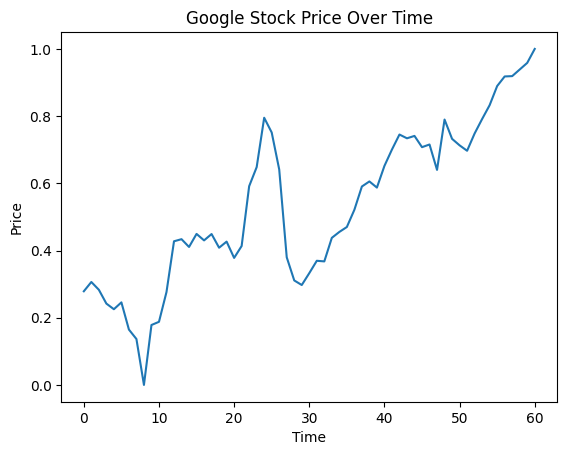

In [11]:
plt.plot(data)
plt.title("Google Stock Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [12]:
print("Total rows:", len(df))
print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Total rows: 61
Train samples: 44
Test samples: 9


In [14]:
model = Sequential()
model.add(SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

C:\Users\riyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [17]:
history = model.fit(X_train, y_train, epochs=30)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.2402
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0780
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.1634
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0707
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0444 
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0768
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0758
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0428
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0229 
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0319
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0361
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0258
Epoch 13/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0170
Epoch 14/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0189
Epoch 15/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0223
Epoch 16/30
2/2 ━━━━━━━━━━━━━━━━

In [18]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step


In [19]:
y_pred = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

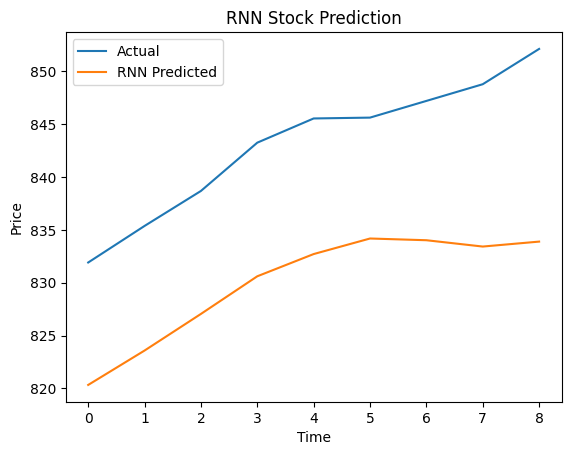

In [20]:
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred, label='RNN Predicted')
plt.title("RNN Stock Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [23]:
rmse_rnn = np.sqrt(mean_squared_error(y_test_inv, y_pred))

In [24]:
print("RNN RMSE:", rmse_rnn)

RNN RMSE: 13.359222545443115
